In [92]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [93]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [94]:
df.clarity.unique()

['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, str): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

In [95]:
df = sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [96]:
df.shape

(53940, 10)

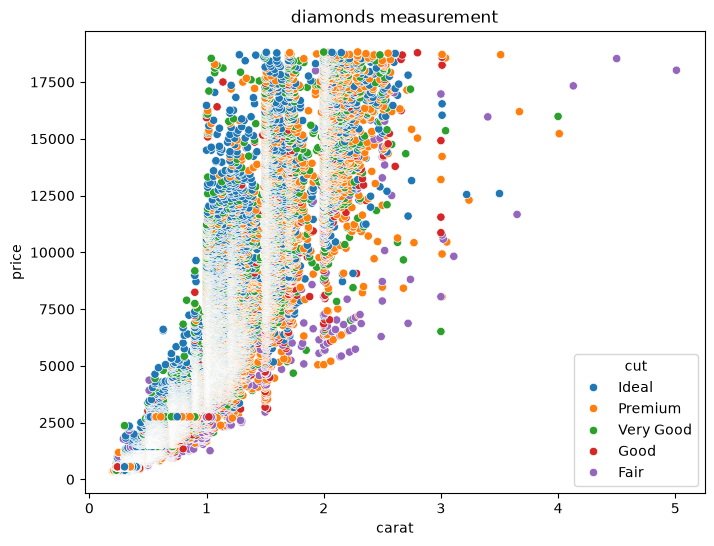

In [97]:
plt.figure(figsize=(8,6))
sns.scatterplot(x = 'carat',y = 'price',data = df,hue= 'cut')
plt.title('diamonds measurement')
plt.xlabel('carat')
plt.ylabel('price')
plt.show()

In [98]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [99]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [100]:
from sklearn.cluster import KMeans
kmean = KMeans(n_clusters=3)

In [101]:
x = df['cut']
df = df.drop(columns=['cut'])
df.head()

,carat,color,clarity,depth,table,price,x,y,z
0,0.23,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [102]:
# Sirf numeric columns select karein
df_numeric = df.select_dtypes(include=['float64', 'int64'])
df_numeric.head()

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75


In [103]:
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(df_numeric)


In [104]:
X_scaled_df = pd.DataFrame(X_scaled, columns=df_numeric.columns)
X_scaled_df.head()

,carat,depth,table,price,x,y,z
0,-1.198168,-0.174092,-1.099672,-0.904095,-1.587837,-1.536196,-1.571129
1,-1.240361,-1.360738,1.585529,-0.904095,-1.641325,-1.658774,-1.741175
2,-1.198168,-3.385019,3.375663,-0.903844,-1.498691,-1.457395,-1.741175
3,-1.071587,0.454133,0.242928,-0.902090,-1.364971,-1.317305,-1.287720
4,-1.029394,1.082358,0.242928,-0.901839,-1.240167,-1.212238,-1.117674


In [105]:
label = kmean.fit_predict(X_scaled_df)
X_scaled_df['cluster'] = label
X_scaled_df.head()

,carat,depth,table,price,x,y,z,cluster
0,-1.198168,-0.174092,-1.099672,-0.904095,-1.587837,-1.536196,-1.571129,1
1,-1.240361,-1.360738,1.585529,-0.904095,-1.641325,-1.658774,-1.741175,1
2,-1.198168,-3.385019,3.375663,-0.903844,-1.498691,-1.457395,-1.741175,1
3,-1.071587,0.454133,0.242928,-0.902090,-1.364971,-1.317305,-1.287720,1
4,-1.029394,1.082358,0.242928,-0.901839,-1.240167,-1.212238,-1.117674,1


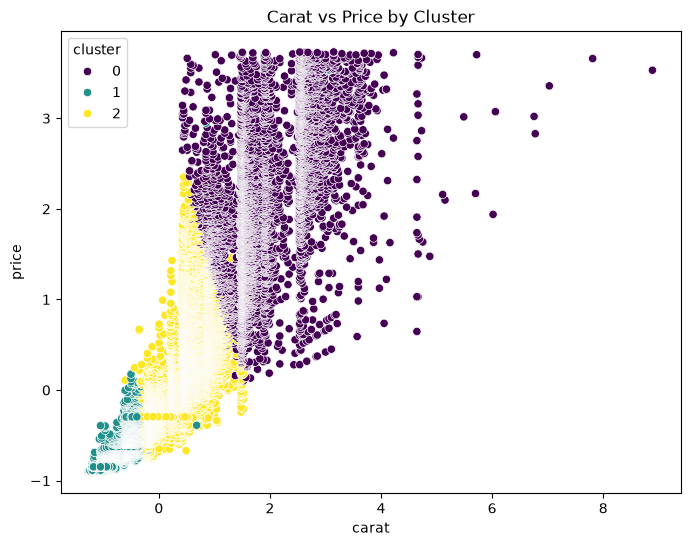

In [106]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='carat', y='price', data=X_scaled_df, hue='cluster', palette='viridis')
plt.title('Carat vs Price by Cluster')
plt.show()

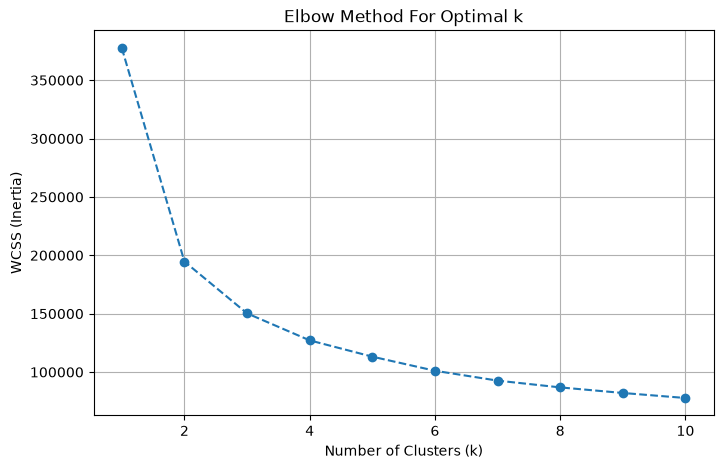

In [107]:
wcss = []
k_range = range(1, 11)

# Note: cluster column hata kar fit karein
features = X_scaled_df.drop(columns=['cluster'])

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

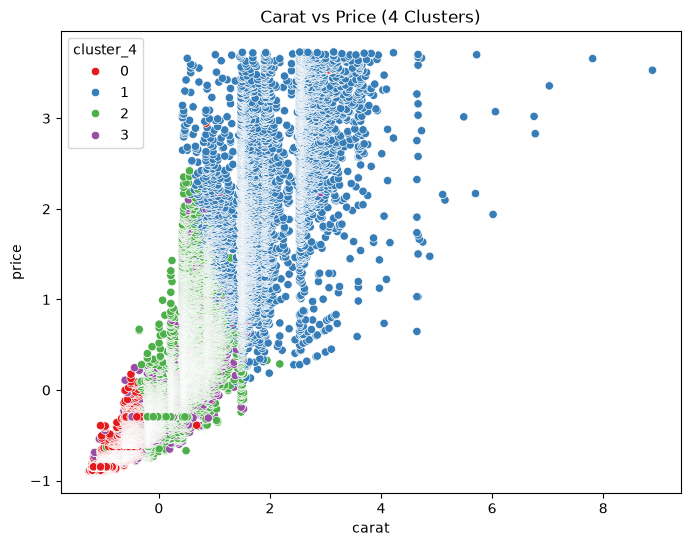

In [108]:
# 4 clusters ke sath model fit karna
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
X_scaled_df['cluster_4'] = kmeans_4.fit_predict(features)

# Carat vs Price par 4 clusters visualize karna
plt.figure(figsize=(8, 6))
sns.scatterplot(x='carat', y='price', data=X_scaled_df, hue='cluster_4', palette='Set1')
plt.title('Carat vs Price (4 Clusters)')
plt.show()

dbscan_cluster
 0     52647
-1      1198
 1        18
 2        16
 7         9
 12        6
 5         5
 13        5
 11        5
 9         5
 3         5
 4         5
 14        5
 10        4
 8         4
 6         3
Name: count, dtype: int64


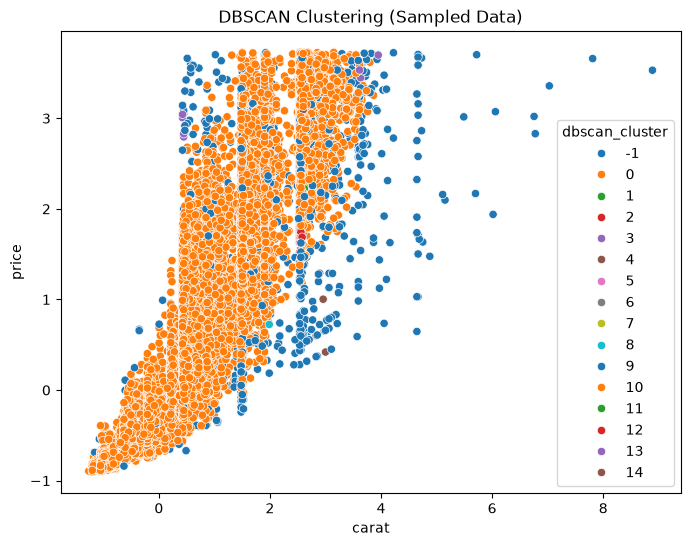

In [111]:
from sklearn.cluster import DBSCAN

# Memory issue na aaye isliye 5000 rows ka sample lein
sample_df = features.sample(n=53940, random_state=42)

# DBSCAN model define karein
# eps: neighborhood distance, min_samples: cluster banane ke liye minimum points
dbscan = DBSCAN(eps=0.5, min_samples=5)
sample_df['dbscan_cluster'] = dbscan.fit_predict(sample_df)

# Clusters check karein (-1 ka matlab outliers/noise hota hai)
print(sample_df['dbscan_cluster'].value_counts())

# Visualize karein
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='carat', 
    y='price', 
    data=sample_df, 
    hue='dbscan_cluster', 
    palette='tab10'
)
plt.title('DBSCAN Clustering (Sampled Data)')
plt.show()

In [112]:
sample_df.head()

,carat,depth,table,price,x,y,z,dbscan_cluster
1388,-1.177071,0.244725,-0.652139,-0.845690,-1.570008,-1.518684,-1.514447,0
50052,-0.459782,-1.221133,-0.204605,-0.434100,-0.259556,-0.275387,-0.394979,0
41645,-0.839523,0.244725,-1.099672,-0.675490,-0.865752,-0.870769,-0.834264,0
42377,-0.776233,-0.662711,-0.204605,-0.658946,-0.723117,-0.739435,-0.791753,0
17244,1.586602,0.384331,-1.099672,0.744021,1.523372,1.431958,1.518036,0
